---
tags: [algorithm, machine-learning, variational]
---

# Hybrid Quantum Neural Network (HQNN)

This tutorial demonstrates how to build a **Hybrid Quantum Neural Network** (HQNN) on Fashion-MNIST that combines classical neural network layers with a quantum variational circuit layer. The quantum layer is defined using Qamomile's `@qkernel` API and integrated into a PyTorch training pipeline via the parameter shift rule.

## Architecture

The entire model — CNN feature extractor, quantum layer, and fusion classifier — is trained **end-to-end from scratch**:

```
Input Image → CNN → π·σ(·) → Quantum Layer → [CNN feats, Q output] → Classifier → Output
```

Here, $\pi \cdot \sigma(\cdot)$ denotes element-wise sigmoid scaling: the CNN output is passed through the sigmoid function $\sigma$ and multiplied by $\pi$, mapping each feature to the interval $(0, \pi)$. This ensures that the rotation angles fed into the quantum layer remain bounded, avoiding wrap-around artifacts that can hinder training.

The fusion classifier takes both classical CNN features and quantum expectation values, allowing the CNN and quantum layer to learn cooperatively from the start.

## Imports and Setup

In [1]:
import math
import os

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

import qamomile.circuit as qmc
from qamomile.circuit.algorithm import ry_layer, rz_layer, cz_entangling_layer
import qamomile.observable as qmo
from qamomile.qiskit import QiskitTranspiler

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

In [2]:
N_QUBITS = 4
N_LAYERS = 2
N_WEIGHTS_PER_LAYER = N_QUBITS * 3  # RZ, RY, RZ per qubit
N_WEIGHTS = N_LAYERS * N_WEIGHTS_PER_LAYER

print(f"Qubits: {N_QUBITS}, Layers: {N_LAYERS}, Trainable weights: {N_WEIGHTS}")
assert N_QUBITS == 4
assert N_LAYERS == 2
# N_WEIGHTS = N_LAYERS * N_QUBITS * 3 (RZ + RY + RZ per qubit per layer).
assert N_WEIGHTS == 24

Qubits: 4, Layers: 2, Trainable weights: 24


## Define the Variational Ansatz with @qkernel

We define a parameterized quantum circuit using Qamomile's `@qkernel` decorator.
The circuit consists of:

1. **Angle encoding**: Each input feature is encoded as an RY rotation on the corresponding qubit.
2. **Variational layers**: Each layer applies RZ–RY–RZ rotations using stdlib layer functions, followed by a CZ entanglement ladder.

The circuit computes the expectation value $\langle H \rangle$ of a given observable.

In [3]:
@qmc.qkernel
def variational_ansatz(
    n_qubits: qmc.UInt,
    n_layers: qmc.UInt,
    inputs: qmc.Vector[qmc.Float],
    weights: qmc.Vector[qmc.Float],
    hamiltonian: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n_qubits, name="q")

    # Angle encoding: embed classical features as RY rotations
    for i in qmc.range(n_qubits):
        q[i] = qmc.ry(q[i], inputs[i])

    # Variational layers using stdlib layer functions
    for layer_idx in qmc.range(n_layers):
        base = layer_idx * n_qubits * 3
        q = rz_layer(q, weights, base)
        q = ry_layer(q, weights, base + n_qubits)
        q = rz_layer(q, weights, base + n_qubits * 2)
        q = cz_entangling_layer(q)

    return qmc.expval(q, hamiltonian)

Let's visualize the circuit structure. With `inline=False`, the stdlib layer functions are shown as compact boxes:

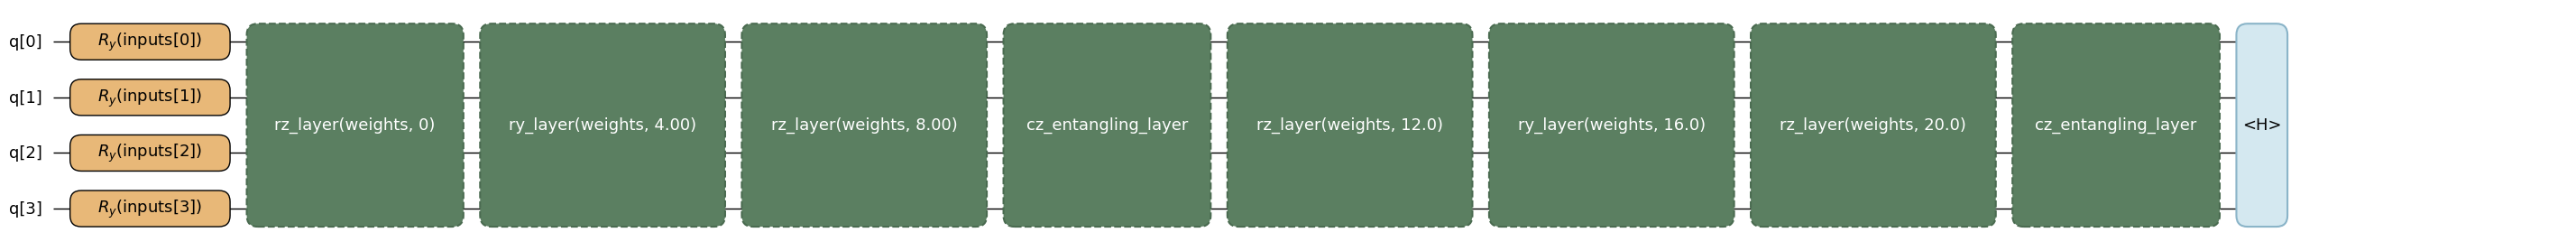

In [4]:
variational_ansatz.draw(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    hamiltonian=qmo.Z(0),
    fold_loops=False,
    inline=False,
)

## Transpile and Estimate Resources

We build one observable per qubit ($\langle Z_i \rangle$) and create an executable for each.
Each observable must span all qubits in the circuit so that the Qiskit estimator
can match qubit counts; we use `Hamiltonian(num_qubits=...)` to ensure proper padding.
Qamomile's `estimate_resources()` gives us gate counts without needing to access the backend circuit directly.

In [5]:
observables = []
for i in range(N_QUBITS):
    obs = qmo.Hamiltonian(num_qubits=N_QUBITS)
    obs.add_term((qmo.PauliOperator(qmo.Pauli.Z, i),), 1.0)
    observables.append(obs)

transpiler = QiskitTranspiler()

executables = [
    transpiler.transpile(
        variational_ansatz,
        bindings={"n_qubits": N_QUBITS, "n_layers": N_LAYERS, "hamiltonian": obs},
        parameters=["inputs", "weights"],
    )
    for obs in observables
]

est = variational_ansatz.estimate_resources(
    bindings={"n_qubits": N_QUBITS, "n_layers": N_LAYERS},
)
print(est)
assert est.qubits == 4
# 4 (input RY encoding) + 2 layers * (4 RZ + 4 RY + 4 RZ) = 28 single-qubit rotations.
assert est.gates.single_qubit == 28
# 2 layers * 3 CZs (linear chain on 4 qubits) = 6 two-qubit Cliffords.
assert est.gates.two_qubit == 6
assert est.gates.total == 34
assert est.gates.rotation_gates == 28

Resource Estimate:
  Qubits: 4
  Gates:
    Total: 34
    Single-qubit: 28
    Two-qubit: 6
    Multi-qubit: 0
    T gates: 0
    Clifford gates: 6
    Rotation gates: 28


## Quantum Forward Pass

The forward pass binds concrete values to the circuit parameters and evaluates $\langle Z_i \rangle$ for each qubit using Qamomile's executor.

In [6]:
executor = transpiler.executor()


def quantum_forward(input_vals: np.ndarray, weight_vals: np.ndarray) -> np.ndarray:
    """Evaluate <Z_i> for each qubit given inputs and weights.

    Args:
        input_vals: Feature values, shape (N_QUBITS,).
        weight_vals: Trainable weights, shape (N_WEIGHTS,).

    Returns:
        Expectation values, shape (N_QUBITS,).
    """
    runtime_bindings = {
        "inputs": list(input_vals),
        "weights": list(weight_vals),
    }
    return np.array(
        [exe.run(executor, bindings=runtime_bindings).result() for exe in executables],
        dtype=float,
    )

In [7]:
# Quick test: random inputs and weights
rng = np.random.default_rng(42)
test_inputs = rng.uniform(-np.pi, np.pi, N_QUBITS)
test_weights = rng.uniform(-np.pi, np.pi, N_WEIGHTS)

expvals = quantum_forward(test_inputs, test_weights)
print("Expectation values:", expvals)
# Z expectation values are bounded in [-1, 1]; one value per qubit.
assert expvals.shape == (N_QUBITS,)
assert all(-1.0 <= float(e) <= 1.0 for e in expvals)

Expectation values: [-0.70960489  0.61071606  0.43586927  0.42650987]


## Parameter Shift Rule for Gradients

To train the quantum layer with PyTorch's autograd, we need gradients of the expectation values with respect to every parameter. The **parameter shift rule** gives us an exact gradient formula for gates of the form $e^{-i\theta G/2}$:

$$
\frac{\partial}{\partial \theta_k} \langle Z_i \rangle
= \frac{1}{2} \Big[
    \langle Z_i \rangle\big|_{\theta_k + \pi/2}
  - \langle Z_i \rangle\big|_{\theta_k - \pi/2}
\Big]
$$

We implement this as a custom `torch.autograd.Function` so that PyTorch can backpropagate through the quantum layer. The implementation uses in-place parameter shifts to avoid allocating copies on every iteration.

In [8]:
SHIFT = math.pi / 2


class QuantumFunction(torch.autograd.Function):
    """Custom autograd function bridging PyTorch and the quantum circuit."""

    @staticmethod
    def forward(ctx, inputs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(inputs, weights)
        # Evaluate the circuit for each sample in the batch
        batch_results = []
        weights_np = weights.detach().cpu().numpy()
        for inp in inputs:
            expvals = quantum_forward(inp.detach().cpu().numpy(), weights_np)
            batch_results.append(expvals)
        return torch.tensor(np.array(batch_results), dtype=inputs.dtype, device=inputs.device)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        inputs, weights = ctx.saved_tensors
        weights_np = weights.detach().cpu().numpy().copy()

        grad_inputs = torch.zeros_like(inputs)
        grad_weights = torch.zeros(weights.shape[0], dtype=weights.dtype, device=weights.device)

        for b, inp in enumerate(inputs):
            inp_np = inp.detach().cpu().numpy().copy()
            g_out = grad_output[b].detach().cpu().numpy()  # shape (N_QUBITS,)

            # Gradient w.r.t. weights (in-place shift to avoid copies)
            for k in range(len(weights_np)):
                weights_np[k] += SHIFT
                fwd_plus = quantum_forward(inp_np, weights_np)
                weights_np[k] -= 2 * SHIFT
                fwd_minus = quantum_forward(inp_np, weights_np)
                weights_np[k] += SHIFT  # restore

                param_grad = (fwd_plus - fwd_minus) / 2.0  # shape (N_QUBITS,)
                grad_weights[k] += np.dot(g_out, param_grad)

            # Gradient w.r.t. inputs (in-place shift to avoid copies)
            for k in range(len(inp_np)):
                inp_np[k] += SHIFT
                fwd_plus = quantum_forward(inp_np, weights_np)
                inp_np[k] -= 2 * SHIFT
                fwd_minus = quantum_forward(inp_np, weights_np)
                inp_np[k] += SHIFT  # restore

                input_grad = (fwd_plus - fwd_minus) / 2.0
                grad_inputs[b, k] = np.dot(g_out, input_grad)

        return grad_inputs, grad_weights

## Quantum Layer as a PyTorch Module

We wrap the autograd function into a standard `nn.Module` so it can be composed with other layers.

In [9]:
class QLayer(nn.Module):
    """PyTorch module wrapping a Qamomile variational circuit."""

    def __init__(self, n_weights: int):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_weights) * 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return QuantumFunction.apply(x, self.weights)

## Prepare Data (Fashion-MNIST)

We use a subset of [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) with 4 visually distinct classes. Fashion-MNIST consists of 28x28 grayscale clothing images.

To keep computation time reasonable, we select 4 classes (T-shirt, Trouser, Sandal, Bag) with 60 training and 30 test samples per class.

In [10]:
N_CLASSES = 4
SELECTED_CLASSES = [0, 1, 5, 8]  # T-shirt, Trouser, Sandal, Bag
CLASS_NAMES = ["T-shirt", "Trouser", "Sandal", "Bag"]
N_TRAIN_PER_CLASS = 2 if docs_test_mode else 60
N_TEST_PER_CLASS = 2 if docs_test_mode else 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

# Use a persistent cache directory to avoid re-downloading
_data_root = os.path.join(os.path.expanduser("~"), ".cache", "fashion_mnist")
full_train = datasets.FashionMNIST(
    root=_data_root, train=True, download=True, transform=transform
)
full_test = datasets.FashionMNIST(
    root=_data_root, train=False, download=True, transform=transform
)


def subset_dataset(dataset, classes, n_per_class):
    """Extract a random subset from the specified classes."""
    images, labels = [], []
    rng_data = np.random.default_rng(0)
    # Use dataset.targets to find indices without loading/transforming all images
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        targets = targets.numpy()
    else:
        targets = np.array(targets)
    for new_label, orig_label in enumerate(classes):
        class_indices = np.where(targets == orig_label)[0]
        chosen = rng_data.choice(class_indices, size=n_per_class, replace=False)
        for idx in chosen:
            img, _ = dataset[int(idx)]
            images.append(img)
            labels.append(new_label)
    return torch.stack(images), torch.tensor(labels)


X_train, y_train = subset_dataset(full_train, SELECTED_CLASSES, N_TRAIN_PER_CLASS)
X_test, y_test = subset_dataset(full_test, SELECTED_CLASSES, N_TEST_PER_CLASS)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# 4 classes x N_PER_CLASS samples each; Fashion-MNIST is 1x28x28 grayscale.
assert X_train.shape == (N_CLASSES * N_TRAIN_PER_CLASS, 1, 28, 28)
assert X_test.shape == (N_CLASSES * N_TEST_PER_CLASS, 1, 28, 28)
print(f"Classes: {CLASS_NAMES}")

Train: torch.Size([240, 1, 28, 28]), Test: torch.Size([120, 1, 28, 28])
Classes: ['T-shirt', 'Trouser', 'Sandal', 'Bag']


## End-to-End Hybrid Model

We define the full hybrid model and train it **end-to-end from scratch**. The CNN feature extractor and quantum layer learn cooperatively — gradients flow from the loss through the fusion classifier, through the quantum layer (via parameter shift rule), and back into the CNN.

```
Input Image → [CNN Feature Extractor] → π·σ(·) → [Quantum Layer] → [CNN feats, Q output] → [Classifier] → Output
```

- **Sigmoid scaling**: $\pi \cdot \sigma(\cdot)$ maps CNN outputs to $(0, \pi)$, keeping angles bounded and avoiding wrap-around.
- **Fusion classifier**: Concatenation of `[CNN features, quantum outputs]` gives the classifier access to both classical and quantum representations.

In [11]:
class EndToEndHybridHQNN(nn.Module):
    """
    End-to-end hybrid model trained from scratch.
    Image -> CNN features -> Quantum layer -> Classifier

    The fusion classifier takes [classical features, quantum outputs]
    giving the model access to both representations.
    """

    def __init__(self, n_qubits: int, n_weights: int, n_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(4, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, n_qubits),
        )
        self.qlayer = QLayer(n_weights)
        self.classifier = nn.Linear(n_qubits * 2, n_classes)

    def forward(self, x: torch.Tensor):
        # CNN features as quantum layer input angles
        feats = math.pi * torch.sigmoid(self.feature_extractor(x))   # shape: (B, N_QUBITS)
        q_out = self.qlayer(feats)                                   # shape: (B, N_QUBITS)

        fused = torch.cat([feats, q_out], dim=1)                     # shape: (B, 2*N_QUBITS)
        logits = self.classifier(fused)
        return logits, feats, q_out


EPOCHS = 2 if docs_test_mode else 10
BATCH_SIZE = 4

torch.manual_seed(42)
hybrid_model = EndToEndHybridHQNN(N_QUBITS, N_WEIGHTS, N_CLASSES)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []

print(f"=== End-to-End Training ({EPOCHS} epochs) ===")
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    total = 0

    for i in range(0, len(X_shuf), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]
        yb = y_shuf[i : i + BATCH_SIZE]

        optimizer.zero_grad()
        logits, feats, q_out = hybrid_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total += len(yb)

    avg_loss = epoch_loss / max(1, math.ceil(total / BATCH_SIZE))
    train_losses.append(avg_loss)

    with torch.no_grad():
        test_logits, _, _ = hybrid_model(X_test)
        test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
        test_accs.append(test_acc)

    print(f"  Epoch {epoch + 1}/{EPOCHS}  loss={avg_loss:.4f}  test_acc={test_acc:.2%}")

=== End-to-End Training (10 epochs) ===


  Epoch 1/10  loss=1.3356  test_acc=55.83%


  Epoch 2/10  loss=0.9415  test_acc=97.50%


  Epoch 3/10  loss=0.6617  test_acc=97.50%


  Epoch 4/10  loss=0.5081  test_acc=96.67%


...

  Epoch 6/10  loss=0.3461  test_acc=96.67%


  Epoch 7/10  loss=0.3025  test_acc=96.67%


  Epoch 8/10  loss=0.2675  test_acc=96.67%


  Epoch 9/10  loss=0.2436  test_acc=96.67%


  Epoch 10/10  loss=0.2324  test_acc=97.50%


In [12]:
# Verify gradients flow to both CNN and quantum layer
xb = X_train[:BATCH_SIZE]
yb = y_train[:BATCH_SIZE]

optimizer.zero_grad()
logits, feats, q_out = hybrid_model(xb)
loss = criterion(logits, yb)
loss.backward()

# ``loss.backward()`` populates ``.grad`` on each parameter; assert here
# so the torch stubs that declare ``.grad`` as ``Tensor | None`` narrow.
# ``nn.Sequential.__getitem__`` is typed as
# ``Tensor | None | Module`` in the torch stub (it accepts both indices
# and slices), so narrow to ``nn.Module`` explicitly before grabbing the
# layer's ``.weight``.
first_conv = hybrid_model.feature_extractor[0]
assert isinstance(first_conv, torch.nn.Module)
first_conv_weight = first_conv.weight  # type: ignore[union-attr]
assert first_conv_weight.grad is not None
quantum_grad = hybrid_model.qlayer.weights.grad
assert quantum_grad is not None
print(
    "feature_extractor first conv grad mean:",
    # zuban treats the chained ``.grad.abs()`` on a stub-typed Tensor as
    # "Tensor not callable"; the runtime call is the standard
    # ``Tensor.abs`` method which produces a Tensor.
    first_conv_weight.grad.abs().mean().item(),  # type: ignore[operator]
)
print("quantum weights grad mean:",
      quantum_grad.abs().mean().item())

optimizer.zero_grad()

feature_extractor first conv grad mean: 0.07927611470222473
quantum weights grad mean: 0.009609604254364967


## Evaluation

In [13]:
with torch.no_grad():
    q_logits, F_test_e2e, q_outputs = hybrid_model(X_test)
    preds = q_logits.argmax(1)
    quantum_acc = (preds == y_test).float().mean().item()

print(f"End-to-end quantum model accuracy: {quantum_acc:.2%}")
print()

for c in range(N_CLASSES):
    mask = y_test == c
    class_acc = (preds[mask] == y_test[mask]).float().mean().item()
    print(f"  {CLASS_NAMES[c]}: {class_acc:.2%}")

End-to-end quantum model accuracy: 97.50%

  T-shirt: 96.67%
  Trouser: 100.00%
  Sandal: 100.00%
  Bag: 93.33%


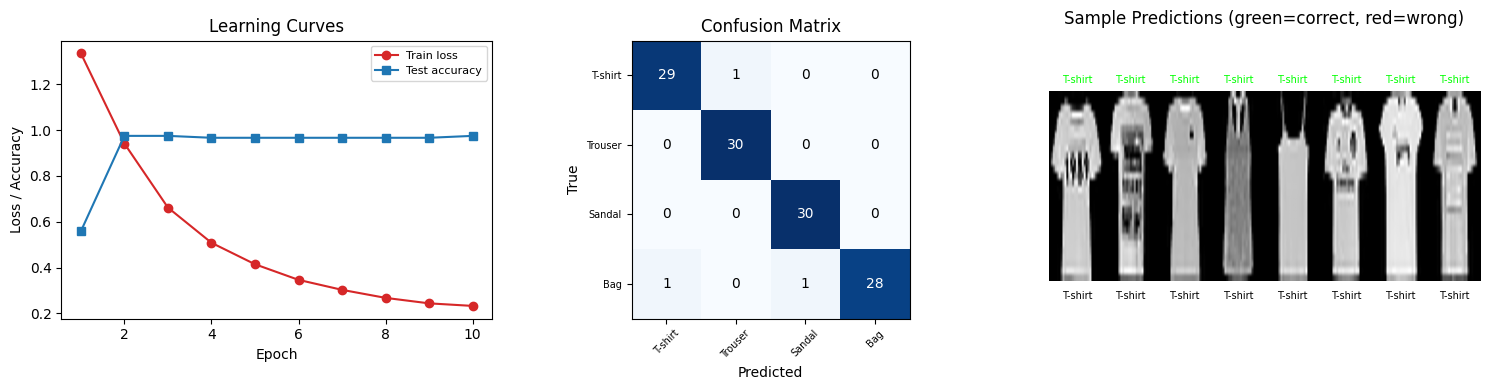

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Learning curves
ax = axes[0]
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, "o-", color="C3", label="Train loss")
ax.plot(epochs_range, test_accs, "s-", color="C0", label="Test accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / Accuracy")
ax.set_title("Learning Curves")
ax.legend(fontsize=8)

# (b) Confusion matrix
conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_test.numpy(), preds.numpy()):
    conf[t, p] += 1
axes[1].imshow(conf, cmap="Blues")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, fontsize=7, rotation=45)
axes[1].set_yticklabels(CLASS_NAMES, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(
            j, i, str(conf[i, j]), ha="center", va="center",
            color="white" if conf[i, j] > conf.max() / 2 else "black",
        )

# (c) Sample images with predictions
n_show = min(8, len(X_test))
sample_imgs = X_test[:n_show, 0].numpy()
combined = np.concatenate(sample_imgs, axis=1)
axes[2].imshow(combined, cmap="gray", aspect="auto")
for i in range(n_show):
    color = "lime" if preds[i] == y_test[i] else "red"
    axes[2].text(
        28 * i + 14, -1.5,
        CLASS_NAMES[preds[i].item()],
        ha="center", va="bottom", fontsize=7, color=color,
        clip_on=False,
    )
    # ``Tensor.item()`` is typed as ``int | float | bool`` in the torch
    # stub even for an integer-typed tensor; the runtime value here is
    # always an ``int`` class label, so cast explicitly for the list index.
    axes[2].text(
        28 * i + 14, 29,
        CLASS_NAMES[int(y_test[i].item())],
        ha="center", va="top", fontsize=7,
        clip_on=False,
    )
axes[2].set_ylim(33, -8)
axes[2].set_title("Sample Predictions (green=correct, red=wrong)", pad=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()